In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import sys
import io, textwrap

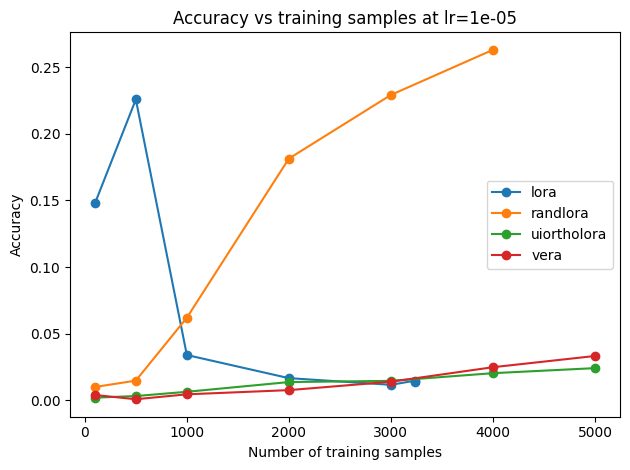

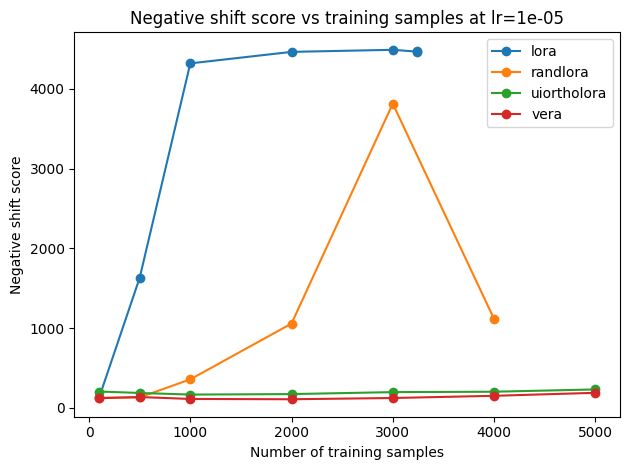

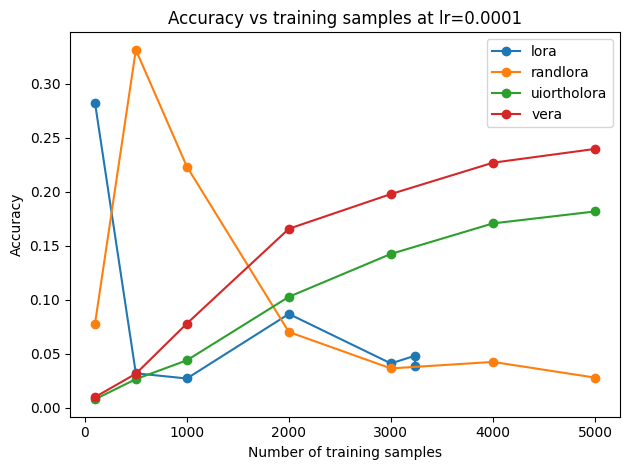

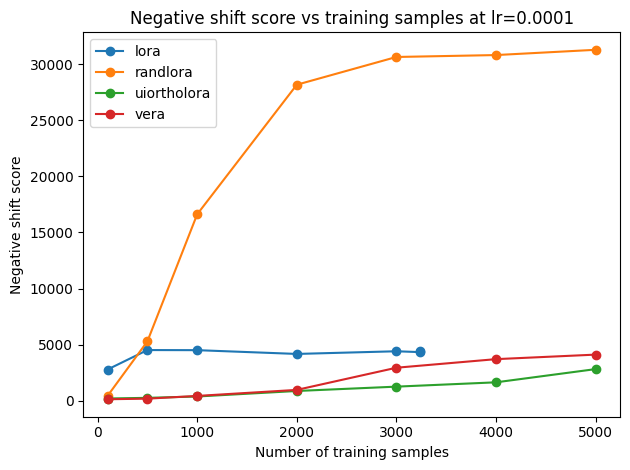

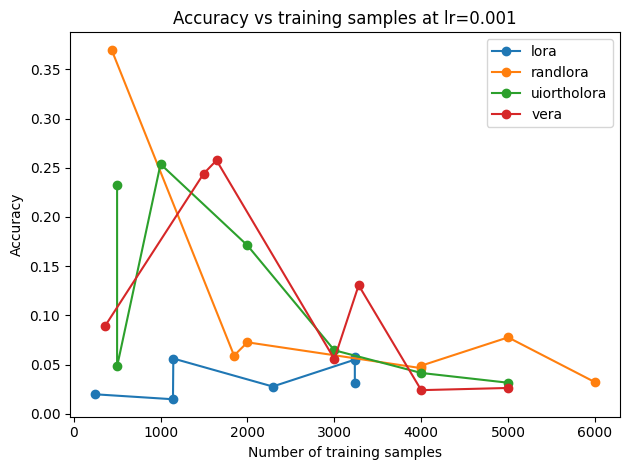

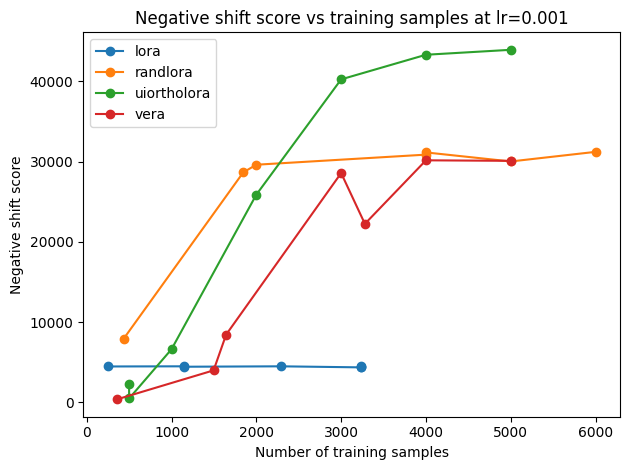

In [3]:
csv_text = "gemma_adapter_results.csv"
df = pd.read_csv(csv_text)

for col in ["lr", "rank", "tr_from_name", "tr_actual", "accuracy",
            "negative_shift_count", "negative_shift_score",
            "positive_shift_count", "positive_shift_score"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["train_samples"] = df["tr_actual"].fillna(df["tr_from_name"])

lrs = sorted(df["lr"].dropna().unique())
adapters = df["adapter_type"].unique()

def plot_metric_for_lr(lr, metric, ylabel):
    sub = df[df["lr"] == lr].copy().sort_values("train_samples")
    plt.figure()
    for adapter in adapters:
        sub_ad = sub[sub["adapter_type"] == adapter]
        if sub_ad.empty:
            continue
        plt.plot(sub_ad["train_samples"], sub_ad[metric],
                 marker="o", label=adapter)
    plt.xlabel("Number of training samples")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs training samples at lr={lr}")
    plt.legend()
    plt.tight_layout()
    plt.show()

for lr in lrs:
    plot_metric_for_lr(lr, "accuracy", "Accuracy")
    plot_metric_for_lr(lr, "negative_shift_score", "Negative shift score")


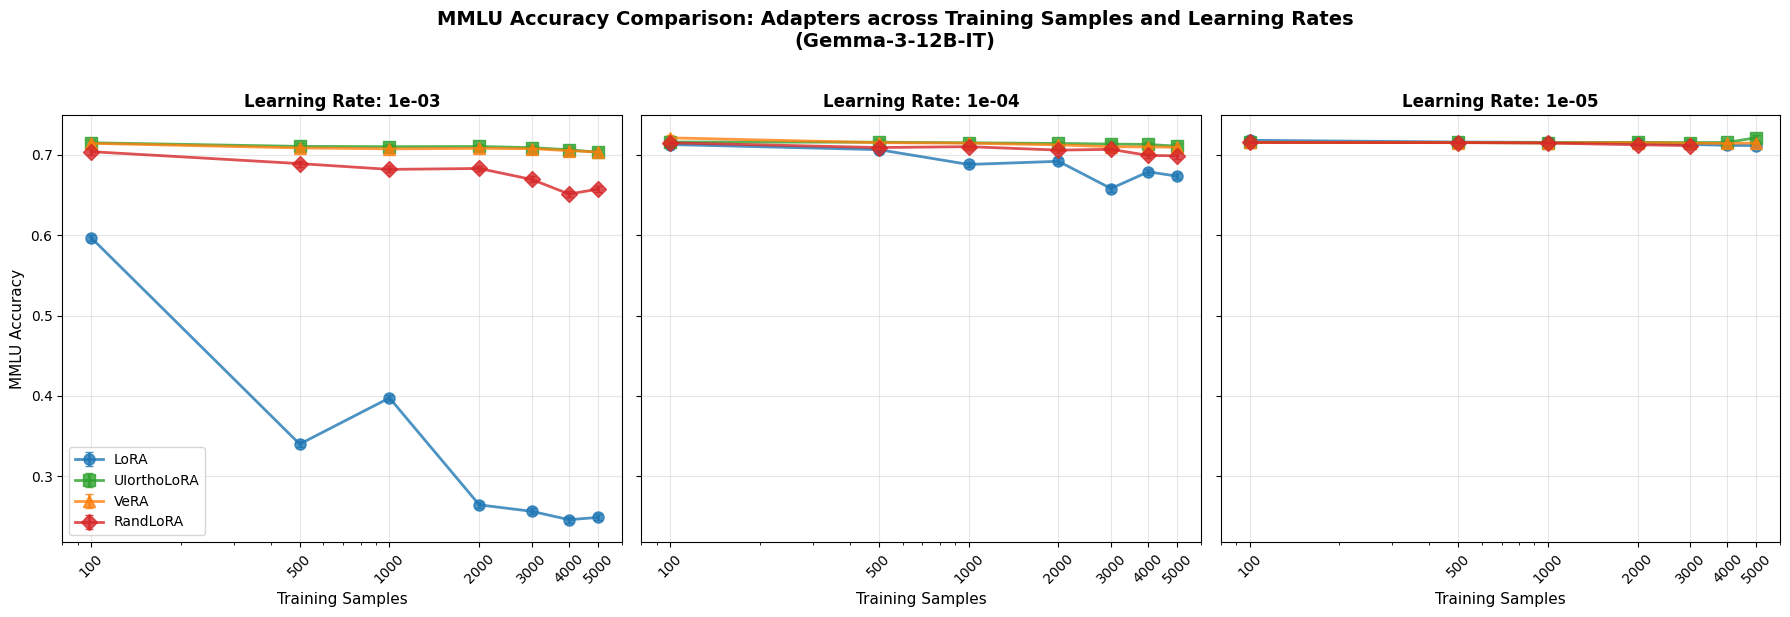

/tmp/ipykernel_4238/140769016.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


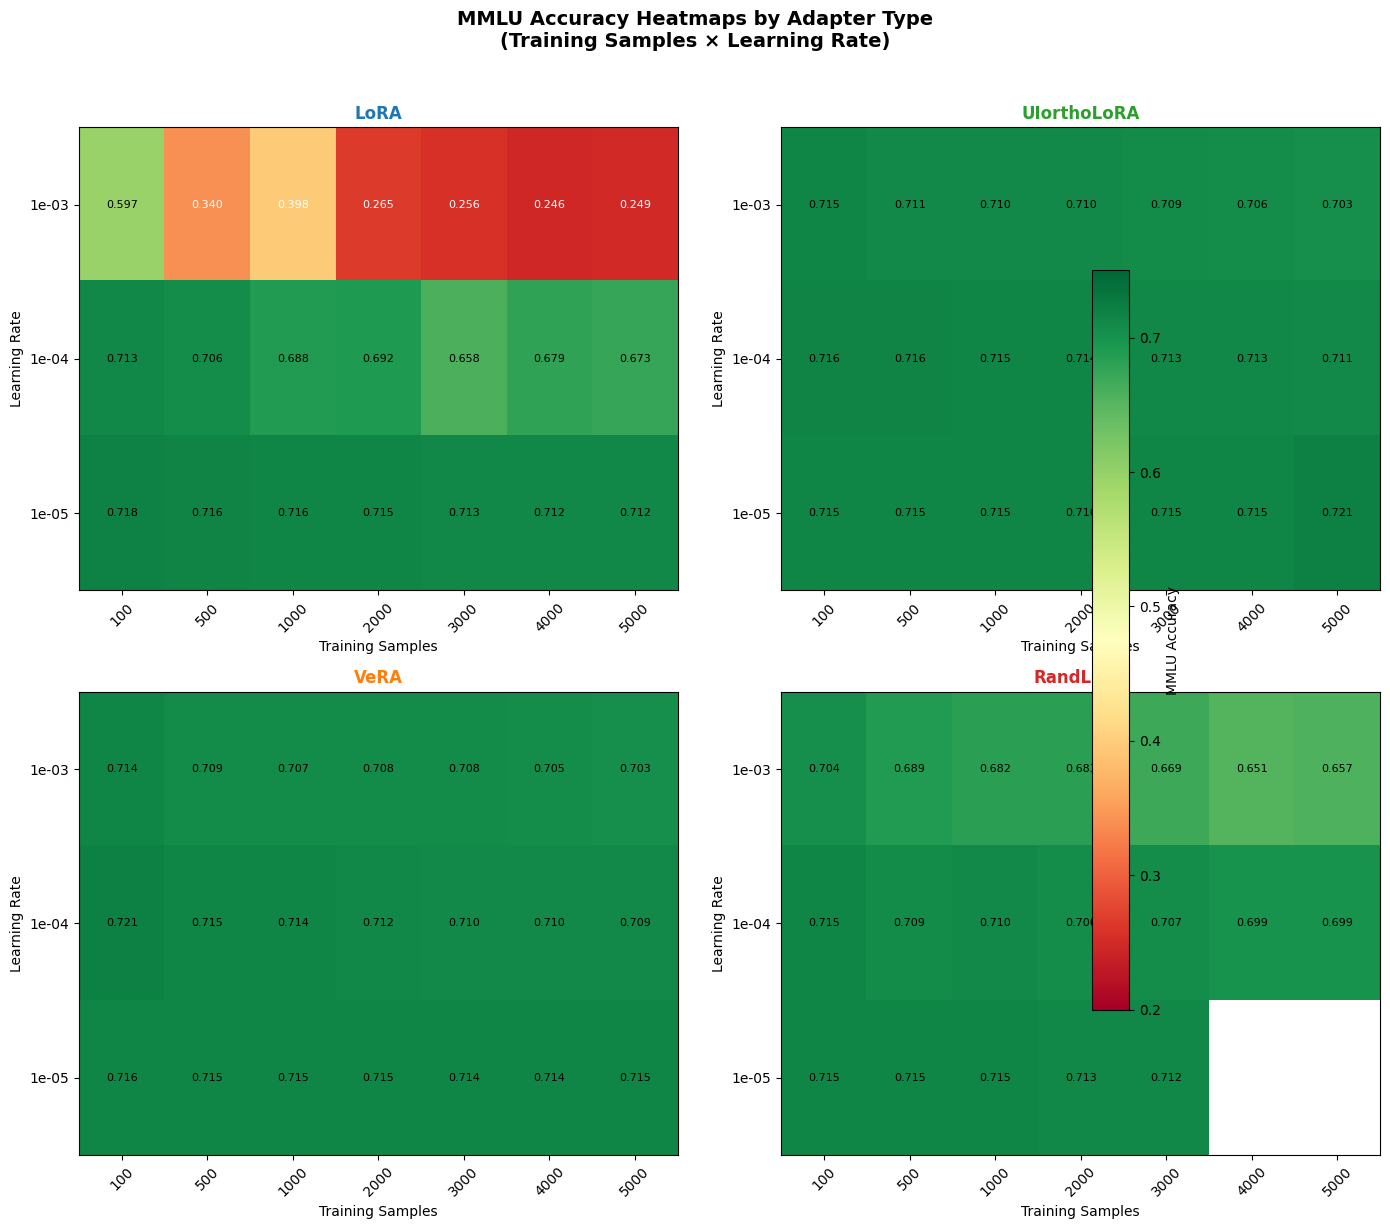

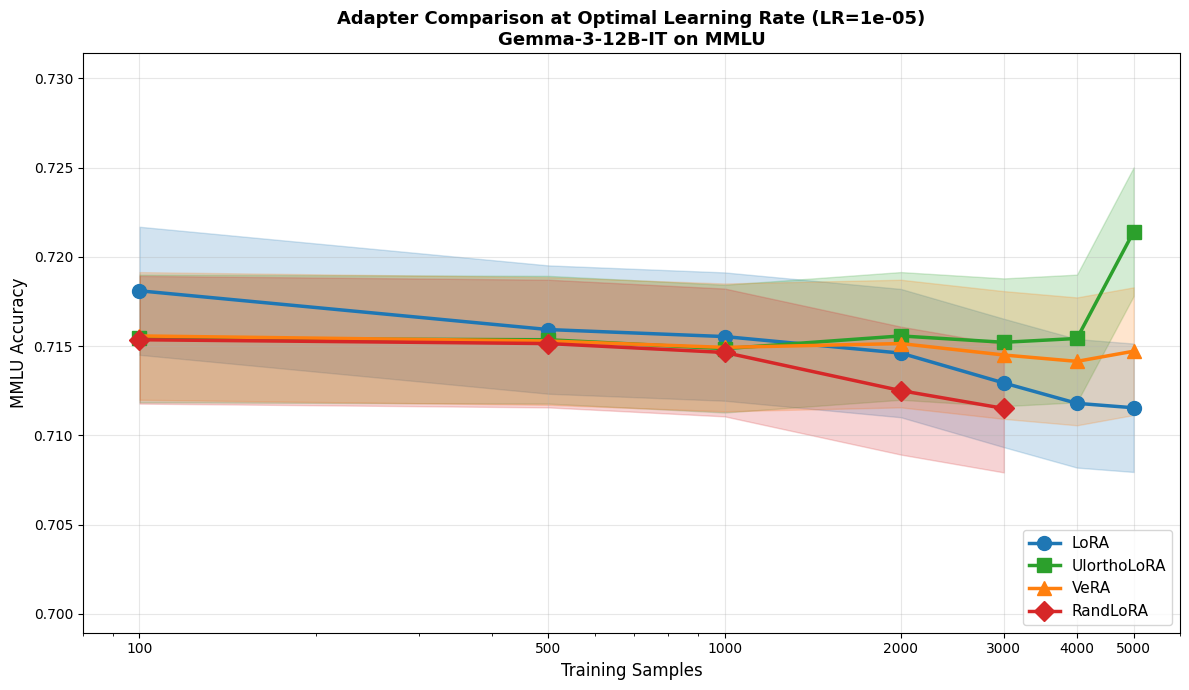


SUMMARY: Best Configuration per Adapter

LoRA:
  Best Accuracy: 0.7214 ± 0.0036
  Training Samples: 100
  Learning Rate: 1e-05

UIorthoLoRA:
  Best Accuracy: 0.7214 ± 0.0036
  Training Samples: 5000
  Learning Rate: 1e-05

VeRA:
  Best Accuracy: 0.7211 ± 0.0036
  Training Samples: 100
  Learning Rate: 1e-04

RandLoRA:
  Best Accuracy: 0.7154 ± 0.0036
  Training Samples: 100
  Learning Rate: 1e-05

COMPARISON: All Adapters at Same Configurations

--- Learning Rate: 1e-03 ---

  Training Samples: 100
    LoRA        : 0.6065
    UIorthoLoRA : 0.7150
    VeRA        : 0.7143
    RandLoRA    : 0.7040

  Training Samples: 500
    LoRA        : 0.3799
    UIorthoLoRA : 0.7105
    VeRA        : 0.7086
    RandLoRA    : 0.6891

  Training Samples: 1000
    LoRA        : 0.4835
    UIorthoLoRA : 0.7102
    VeRA        : 0.7074
    RandLoRA    : 0.6819

  Training Samples: 2000
    LoRA        : 0.2722
    UIorthoLoRA : 0.7104
    VeRA        : 0.7080
    RandLoRA    : 0.6830

  Training Sample

In [7]:
# Read data from file
csv_file = "../results/mmlu/mmlu/mmlu_summary.csv"
df = pd.read_csv(csv_file)

# Parse model name to extract adapter type, training samples, and learning rate
def parse_model_name(name):
    # Extract adapter type
    if '_uiortholora_' in name:
        adapter = 'UIorthoLoRA'
    elif '_randlora_' in name:
        adapter = 'RandLoRA'
    elif '_vera_' in name:
        adapter = 'VeRA'
    elif '_lora_' in name:
        adapter = 'LoRA'
    else:
        adapter = 'Unknown'
    
    # Extract training samples
    tr_match = re.search(r'_tr(\d+)_', name)
    train_samples = int(tr_match.group(1)) if tr_match else None
    
    # Extract learning rate
    lr_match = re.search(r'_lr([\d\w\-]+)$', name)
    if lr_match:
        lr_str = lr_match.group(1)
        lr = float(lr_str.replace('e-', 'e-'))
    else:
        lr = None
    
    return adapter, train_samples, lr

# Apply parsing
df['adapter'], df['train_samples'], df['lr'] = zip(*df['model_name'].apply(parse_model_name))

# Filter out any parsing errors
df = df[df['adapter'] != 'Unknown']
df = df[df['train_samples'].notna()]
df = df[df['lr'].notna()]

# Create readable LR labels
df['lr_label'] = df['lr'].apply(lambda x: f'{x:.0e}')

# Define colors and markers for adapters
adapter_colors = {
    'LoRA': '#1f77b4',
    'UIorthoLoRA': '#2ca02c',
    'VeRA': '#ff7f0e',
    'RandLoRA': '#d62728'
}

adapter_markers = {
    'LoRA': 'o',
    'UIorthoLoRA': 's',
    'VeRA': '^',
    'RandLoRA': 'D'
}

# Get unique values
learning_rates = sorted(df['lr'].unique(), reverse=True)
train_samples_list = sorted(df['train_samples'].unique())
adapters = ['LoRA', 'UIorthoLoRA', 'VeRA', 'RandLoRA']

# Create figure with subplots for each learning rate
fig, axes = plt.subplots(1, len(learning_rates), figsize=(6*len(learning_rates), 6), sharey=True)
if len(learning_rates) == 1:
    axes = [axes]

fig.suptitle('MMLU Accuracy Comparison: Adapters across Training Samples and Learning Rates\n(Gemma-3-12B-IT)', 
             fontsize=14, fontweight='bold', y=1.02)

for idx, lr in enumerate(learning_rates):
    ax = axes[idx]
    lr_data = df[df['lr'] == lr]
    
    for adapter in adapters:
        adapter_data = lr_data[lr_data['adapter'] == adapter]
        if len(adapter_data) > 0:
            # Group by train_samples and take mean (in case of duplicates)
            grouped = adapter_data.groupby('train_samples').agg({
                'mmlu_acc': 'mean',
                'mmlu_acc_stderr': 'mean'
            }).reset_index()
            
            ax.errorbar(
                grouped['train_samples'], 
                grouped['mmlu_acc'],
                yerr=grouped['mmlu_acc_stderr'],
                label=adapter,
                color=adapter_colors[adapter],
                marker=adapter_markers[adapter],
                markersize=8,
                capsize=3,
                linewidth=2,
                alpha=0.8
            )
    
    ax.set_xlabel('Training Samples', fontsize=11)
    ax.set_title(f'Learning Rate: {lr:.0e}', fontsize=12, fontweight='bold')
    ax.set_xscale('log')
    ax.set_xticks(train_samples_list)
    ax.set_xticklabels([str(int(x)) for x in train_samples_list], rotation=45)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(min(train_samples_list) * 0.8, max(train_samples_list) * 1.2)

axes[0].set_ylabel('MMLU Accuracy', fontsize=11)
axes[0].legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.savefig('adapter_comparison_by_lr.png', dpi=150, bbox_inches='tight')
plt.show()

# Create heatmap comparison
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 12))
fig2.suptitle('MMLU Accuracy Heatmaps by Adapter Type\n(Training Samples × Learning Rate)', 
              fontsize=14, fontweight='bold', y=1.02)

for idx, adapter in enumerate(adapters):
    ax = axes2[idx // 2, idx % 2]
    adapter_data = df[df['adapter'] == adapter]
    
    # Create pivot table
    pivot = adapter_data.pivot_table(
        values='mmlu_acc', 
        index='lr', 
        columns='train_samples',
        aggfunc='mean'
    )
    
    # Sort index (learning rates) in descending order
    pivot = pivot.sort_index(ascending=False)
    
    # Create heatmap
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0.2, vmax=0.75)
    
    # Add text annotations
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                text_color = 'white' if val < 0.5 else 'black'
                ax.text(j, i, f'{val:.3f}', ha='center', va='center', 
                       fontsize=8, color=text_color)
    
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([str(int(x)) for x in pivot.columns], rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{x:.0e}' for x in pivot.index])
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('Learning Rate')
    ax.set_title(f'{adapter}', fontsize=12, fontweight='bold', color=adapter_colors[adapter])

# Add colorbar
fig2.colorbar(im, ax=axes2, label='MMLU Accuracy', shrink=0.8)
plt.tight_layout()
plt.savefig('adapter_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

# Create direct comparison plot for best LR (1e-5)
fig3, ax3 = plt.subplots(figsize=(12, 7))

best_lr = min(learning_rates)  # Usually 1e-5 is the smallest/best
lr_data = df[df['lr'] == best_lr]

for adapter in adapters:
    adapter_data = lr_data[lr_data['adapter'] == adapter]
    if len(adapter_data) > 0:
        grouped = adapter_data.groupby('train_samples').agg({
            'mmlu_acc': 'mean',
            'mmlu_acc_stderr': 'mean'
        }).reset_index()
        
        ax3.fill_between(
            grouped['train_samples'],
            grouped['mmlu_acc'] - grouped['mmlu_acc_stderr'],
            grouped['mmlu_acc'] + grouped['mmlu_acc_stderr'],
            alpha=0.2,
            color=adapter_colors[adapter]
        )
        ax3.plot(
            grouped['train_samples'], 
            grouped['mmlu_acc'],
            label=adapter,
            color=adapter_colors[adapter],
            marker=adapter_markers[adapter],
            markersize=10,
            linewidth=2.5
        )

ax3.set_xlabel('Training Samples', fontsize=12)
ax3.set_ylabel('MMLU Accuracy', fontsize=12)
ax3.set_title(f'Adapter Comparison at Optimal Learning Rate (LR={best_lr:.0e})\nGemma-3-12B-IT on MMLU', 
              fontsize=13, fontweight='bold')
ax3.set_xscale('log')
ax3.set_xticks(train_samples_list)
ax3.set_xticklabels([str(int(x)) for x in train_samples_list])
ax3.legend(loc='lower right', fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(min(train_samples_list) * 0.8, max(train_samples_list) * 1.2)

# Auto-adjust y-axis based on data
y_min = lr_data['mmlu_acc'].min() - 0.01
y_max = lr_data['mmlu_acc'].max() + 0.01
ax3.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('adapter_comparison_best_lr.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics table
print("\n" + "="*80)
print("SUMMARY: Best Configuration per Adapter")
print("="*80)

for adapter in adapters:
    adapter_data = df[df['adapter'] == adapter]
    if len(adapter_data) > 0:
        best_row = adapter_data.loc[adapter_data['mmlu_acc'].idxmax()]
        print(f"\n{adapter}:")
        print(f"  Best Accuracy: {best_row['mmlu_acc']:.4f} ± {best_row['mmlu_acc_stderr']:.4f}")
        print(f"  Training Samples: {int(best_row['train_samples'])}")
        print(f"  Learning Rate: {best_row['lr']:.0e}")

# Print comparison at fixed configurations
print("\n" + "="*80)
print("COMPARISON: All Adapters at Same Configurations")
print("="*80)

for lr in learning_rates:
    print(f"\n--- Learning Rate: {lr:.0e} ---")
    for ts in sorted(df['train_samples'].unique()):
        print(f"\n  Training Samples: {int(ts)}")
        for adapter in adapters:
            row = df[(df['adapter'] == adapter) & (df['train_samples'] == ts) & (df['lr'] == lr)]
            if len(row) > 0:
                acc = row['mmlu_acc'].values[0]
                print(f"    {adapter:12s}: {acc:.4f}")
            else:
                print(f"    {adapter:12s}: N/A")